# Predicting repo stars (DNN vs baselines)

Part A fits RF / gradient boosting / XGBoost / CatBoost. Part B is a dense Keras net with Keras Tuner. Part C is a small LSTM on a made-up weekly sequence from `commits` — only there so the notebook can run an LSTM without GH Archive data yet.

Holdout metrics: \(R^2\), MAE, MSE.


In [1]:
import os
import sys
import warnings
from pathlib import Path

# Use Python 3.12 or 3.13 + requirements-local.txt so TensorFlow installs.

if sys.version_info >= (3, 14):
    raise RuntimeError(
        "TensorFlow has no PyPI wheels for Python 3.14+. Use Python 3.12 or 3.13, "
        "recreate .venv, then pip install -r requirements-local.txt (see README)."
    )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import keras_tuner as kt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from catboost import CatBoostRegressor

try:
    from xgboost import XGBRegressor

    _HAS_XGB = True
except Exception as _xgb_err:
    XGBRegressor = None  # type: ignore
    _HAS_XGB = False
    print("XGBoost import skipped (macOS: often need `brew install libomp`):", _xgb_err)

warnings.filterwarnings("ignore", category=UserWarning)
tf.random.set_seed(42)
np.random.seed(42)

def metrics_dict(y_true, y_pred):
    return {
        "r2": float(r2_score(y_true, y_pred)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "mse": float(mean_squared_error(y_true, y_pred)),
    }


In [2]:
_here = Path.cwd()
_candidates = [
    _here / "PreprocessData.csv",
    _here.parent / "data" / "notebook_inputs" / "PreprocessData.csv",
]
path = next((p.resolve() for p in _candidates if p.exists()), None)
if path is None:
    raise FileNotFoundError("PreprocessData.csv not found. Run: python3 scripts/ingest_data.py --fetch-only")

data_df = pd.read_csv(path).iloc[:, 1:]  # drop index column from the legacy export

if "stars" not in data_df.columns:
    raise KeyError("Expected a 'stars' target column.")

X_df = data_df.drop(columns=["stars"])
y = data_df["stars"].astype(np.float32)

commits_series = X_df["commits"].astype(np.float32) if "commits" in X_df.columns else None

if commits_series is not None:
    X_train_df, X_test_df, y_train, y_test, com_tr, com_te = train_test_split(
        X_df, y, commits_series, test_size=0.10, random_state=42
    )
else:
    X_train_df, X_test_df, y_train, y_test = train_test_split(
        X_df, y, test_size=0.10, random_state=42
    )
    com_tr = com_te = None

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df).astype(np.float32)
X_test = scaler.transform(X_test_df).astype(np.float32)
n_features = X_train.shape[1]
print("Train:", X_train.shape, "Test:", X_test.shape, "Features:", n_features)


Train: (95503, 54) Test: (10612, 54) Features: 54


## Part A — Baselines

Same train/test split and scaling as the neural net below.


In [3]:
baseline_rows = []

rf = RandomForestRegressor(
    n_estimators=200, max_depth=None, n_jobs=-1, random_state=42, verbose=0
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
baseline_rows.append(("Random Forest", metrics_dict(y_test, pred_rf)))

gbr = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42, verbose=0
)
gbr.fit(X_train, y_train)
pred_gbr = gbr.predict(X_test)
baseline_rows.append(("Gradient Boosting (sklearn)", metrics_dict(y_test, pred_gbr)))

if _HAS_XGB and XGBRegressor is not None:
    xgb = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )
    xgb.fit(X_train, y_train)
    pred_xgb = xgb.predict(X_test)
    baseline_rows.append(("XGBoost", metrics_dict(y_test, pred_xgb)))
else:
    print("Skipping XGBoost baseline (OpenMP / lib missing on some Macs; see README).")

cat = CatBoostRegressor(
    iterations=600,
    depth=8,
    learning_rate=0.05,
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
)
X_tr_c, X_val_c, y_tr_c, y_val_c = train_test_split(
    X_train, y_train, test_size=0.15, random_state=0
)
cat.fit(
    X_tr_c,
    y_tr_c,
    eval_set=(X_val_c, y_val_c),
    early_stopping_rounds=40,
    verbose=False,
)
pred_cat = cat.predict(X_test)
baseline_rows.append(("CatBoost", metrics_dict(y_test, pred_cat)))

baseline_df = pd.DataFrame(
    [{"model": m, **v} for m, v in baseline_rows]
).set_index("model")
print(baseline_df.sort_values("r2", ascending=False).to_string())


                                   r2         mae            mse
model                                                           
XGBoost                      0.824630  237.824051  470390.750000
CatBoost                     0.820648  237.168582  481070.417241
Random Forest                0.795444  252.105109  548675.177961
Gradient Boosting (sklearn)  0.785854  257.035183  574398.489402


## Part B — Feed-forward net

Dense layers + batch norm + dropout + L2; tuner searches depth/width/dropout/L2/lr. Env vars `KT_MAX_TRIALS`, `KT_EPOCHS`, `KT_BATCH` control runtime.


In [4]:
input_dim = n_features
tuner_dir = Path(os.environ.get("KERAS_TUNER_DIR", str(Path.cwd() / "keras_tuner_scratch")))
tuner_dir.mkdir(parents=True, exist_ok=True)


def build_ffnn(hp: kt.HyperParameters) -> keras.Model:
    l2 = hp.Float("l2", 1e-5, 5e-3, sampling="log")
    reg = regularizers.l2(l2)
    n_layers = hp.Int("n_dense_layers", 1, 3)
    dropout = hp.Float("dropout", 0.1, 0.45, step=0.05)
    lr = hp.Float("learning_rate", 1e-4, 3e-3, sampling="log")

    model = keras.Sequential(name="ffnn_stars")
    model.add(layers.Input(shape=(input_dim,)))
    for i in range(n_layers):
        units = hp.Int(f"units_{i}", min_value=64, max_value=256, step=32)
        model.add(layers.Dense(units, activation="relu", kernel_regularizer=reg))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation=None))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"],
    )
    return model


tuner = kt.RandomSearch(
    hypermodel=build_ffnn,
    objective=kt.Objective("val_loss", direction="min"),
    max_trials=int(os.environ.get("KT_MAX_TRIALS", "8")),
    directory=str(tuner_dir),
    project_name="stars_ffnn",
    overwrite=os.environ.get("KT_OVERWRITE", "1") == "1",
)

es = EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True, verbose=1)
rlr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
)

tuner.search(
    X_train,
    y_train,
    validation_split=0.15,
    epochs=int(os.environ.get("KT_EPOCHS", "40")),
    batch_size=int(os.environ.get("KT_BATCH", "256")),
    callbacks=[es, rlr],
    verbose=1,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:", best_hp.values)

best_model = tuner.get_best_models(1)[0]
pred_nn = best_model.predict(X_test, verbose=0).ravel()
nn_metrics = metrics_dict(y_test, pred_nn)
print("FNN test:", nn_metrics)


Trial 8 Complete [00h 00m 11s]
val_loss: 1035162.5625

Best val_loss So Far: 555144.375
Total elapsed time: 00h 02m 22s
Best hyperparameters: {'l2': 0.0029493315454139665, 'n_dense_layers': 3, 'dropout': 0.25, 'learning_rate': 0.0026680277954615893, 'units_0': 128, 'units_1': 64, 'units_2': 64}


FNN test: {'r2': 0.7928508520126343, 'mae': 276.8127136230469, 'mse': 555631.375}



Test set (higher R² is better)
                                   r2         mae            mse
model                                                           
XGBoost                      0.824630  237.824051  470390.750000
CatBoost                     0.820648  237.168582  481070.417241
Random Forest                0.795444  252.105109  548675.177961
Neural Net (FNN, tuned)      0.792851  276.812714  555631.375000
Gradient Boosting (sklearn)  0.785854  257.035183  574398.489402


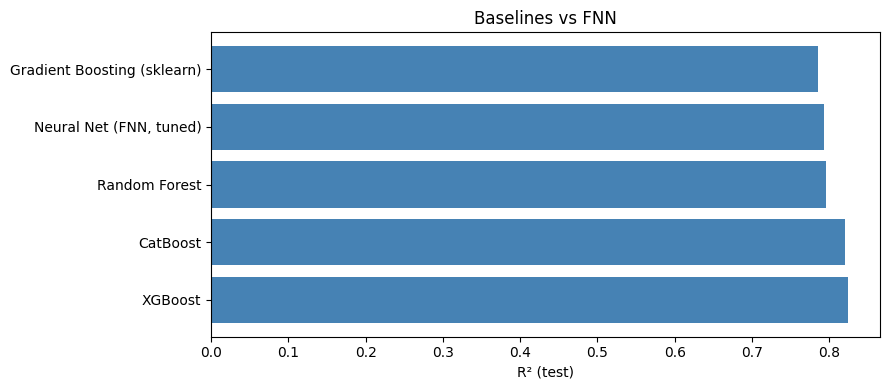


Best baseline R²: 0.8246 | FNN R²: 0.7929


In [5]:
rows = baseline_df.reset_index().rename(columns={"index": "model"})
rows = pd.concat(
    [
        rows,
        pd.DataFrame(
            [{"model": "Neural Net (FNN, tuned)", "r2": nn_metrics["r2"], "mae": nn_metrics["mae"], "mse": nn_metrics["mse"]}]
        ),
    ],
    ignore_index=True,
)

summary = rows.set_index("model").sort_values("r2", ascending=False)
print("\nTest set (higher R² is better)")
print(summary.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
xpos = np.arange(len(summary))
ax.barh(xpos, summary["r2"].values, color="steelblue")
ax.set_yticks(xpos)
ax.set_yticklabels(summary.index.tolist())
ax.set_xlabel("R² (test)")
ax.set_title("Baselines vs FNN")
plt.tight_layout()
plt.show()

best_baseline_r2 = summary.drop(index=["Neural Net (FNN, tuned)"], errors="ignore")["r2"].max()
print(f"\nBest baseline R²: {best_baseline_r2:.4f} | FNN R²: {nn_metrics['r2']:.4f}")


## Part C — LSTM (placeholder)

Fake 5-step sequences from `commits` so there is something temporal to feed the LSTM. Swap in real weekly features later if you add GH Archive.


In [6]:
if com_tr is None:
    print("No commits column, skipping LSTM.")
else:
    rng = np.random.default_rng(42)

    def weekly_proxy(commit_series: pd.Series | np.ndarray) -> np.ndarray:
        c = np.maximum(np.asarray(commit_series, dtype=np.float32), 0.0)
        T = 5
        seq = np.stack(
            [c * (1.0 + 0.04 * t) + rng.normal(0, 0.02 * (c + 1.0), size=c.shape) for t in range(T)],
            axis=1,
        )
        return seq[..., np.newaxis]

    seq_train = weekly_proxy(com_tr)
    seq_test = weekly_proxy(com_te)

    lstm = keras.Sequential(
        [
            layers.Input(shape=seq_train.shape[1:]),
            layers.LSTM(32, return_sequences=False),
            layers.Dropout(0.2),
            layers.Dense(16, activation="relu"),
            layers.Dense(1),
        ],
        name="lstm_weekly_proxy",
    )
    lstm.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    lstm.fit(
        seq_train,
        y_train,
        validation_split=0.15,
        epochs=25,
        batch_size=512,
        callbacks=[
            EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
        ],
        verbose=1,
    )
    pred_lstm = lstm.predict(seq_test, verbose=0).ravel()
    lstm_m = metrics_dict(y_test, pred_lstm)
    print("LSTM test:", lstm_m)


Epoch 1/25


  1/159 ━━━━━━━━━━━━━━━━━━━━ 1:54 724ms/step - loss: 4739328.5000 - mae: 696.5470

 23/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4486776.6522 - mae: 658.7610    

 44/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4170253.8409 - mae: 648.6439

 65/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3860190.6231 - mae: 639.5712

...

106/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3081558.3443 - mae: 579.6431

128/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3001954.7148 - mae: 577.4130

149/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2939241.1393 - mae: 575.7932

159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2581426.5000 - mae: 566.3836 - val_loss: 2420813.2500 - val_mae: 557.0162


LSTM test: {'r2': 0.046613216400146484, 'mae': 592.2572021484375, 'mse': 2557247.25}
